# Pair Trading

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import butter, filtfilt

In [2]:
tickers = ['YPF', 'GGAL', 'BMA', 'SUPV', 'LOMA', 'CEPU', 'PAM', 'TGS']

start = '2008-01-01'
end = '2025-01-01'

raw = yf.download(
    tickers,
    start=start,
    end=end,
    auto_adjust=False
)

data = raw['Close']

[*********************100%***********************]  8 of 8 completed


In [3]:
# Colores fijos por ticker
color_map = {
    'YPF': 'tab:blue',
    'GGAL': 'tab:orange',
    'BMA': 'tab:green',
    'SUPV': 'tab:red',
    'LOMA': 'tab:purple',
    'CEPU': 'tab:brown',
    'PAM': 'tab:pink',
    'TGS': 'tab:gray',
}


In [4]:
# Retornos diarios de todos los tickers y el índice sintético del panel
# (promedio equal-weight, base para calcular la divergencia de cada acción)
retornos_todos = data[tickers].pct_change().dropna()

retorno_promedio_panel = retornos_todos.mean(axis=1)
indice_panel = (1 + retorno_promedio_panel).cumprod()


Un gran problema en el que queremos intentar meternos es el de generar señales de compra y venta de acciones (en este caso) argentinas. 

Para esto hay muchos modelos ya existentes, pero uno que nos generó mucha curosidad es el de Pair Trading.
El concepto es simple. Queremos agrupar acciones relacionadas, identificar cuando una acción no está siguiendo al grupo y en base a eso decidir si comprar o vender.

Uno de los problemas es que las acciones argentinas generalmente no suelen ser acciones muy estables. Presentan mucha volatilidad.
Es por eso que necesitamos ser inteligentes con la estrategia que utilicemos.

### Pair Trading usando z-score 

El Pair Trading asume que los mercados son elásticos: si algo se estira demasiado, eventualmente vuelve a la media.

En acciones argentinas esta idea es especialmente aprovechable: ya vimos que las 8 acciones del panel están fuertemente correlacionadas entre sí, así que en vez de comparar una acción contra otra puntual, la comparamos contra el **promedio del panel**. Cuando una se aleja demasiado de ese comportamiento conjunto, apostamos a que converge de nuevo.

Para esto usamos un **z-score**: mide qué tan lejos está un valor de su comportamiento habitual, en unidades de desvío estándar.

Los residuos de cada acción tienen escalas diferentes; una desviación de 0.05 puede ser enorme para una acción y normal para otra. Por eso normalizamos:

$$z_t = \frac{e_t - \mu_t}{\sigma_t}$$

donde:
- $e_t$: residuo actual (en nuestro caso, la divergencia del ticker contra el índice del panel hoy).
- $\mu_t$: media reciente de los residuos (promedio de la divergencia en los últimos 60 días, `ventana_zscore = 60`).
- $\sigma_t$: desvío estándar reciente de los residuos.

**Interpretación:**
- $z_t = -2$: la acción está aproximadamente dos desvíos por debajo de su comportamiento habitual (está "barata").
- $z_t = 0$: está cerca de su nivel normal.
- $z_t = 2$: está aproximadamente dos desvíos por encima de su comportamiento habitual (está "cara").

---

En nuestro caso definimos un umbral de 1.5 (`umbral_z = 1.5`): compramos la acción cuando $z_t < -1.5$ y la vendemos cuando $z_t > 1.5$.

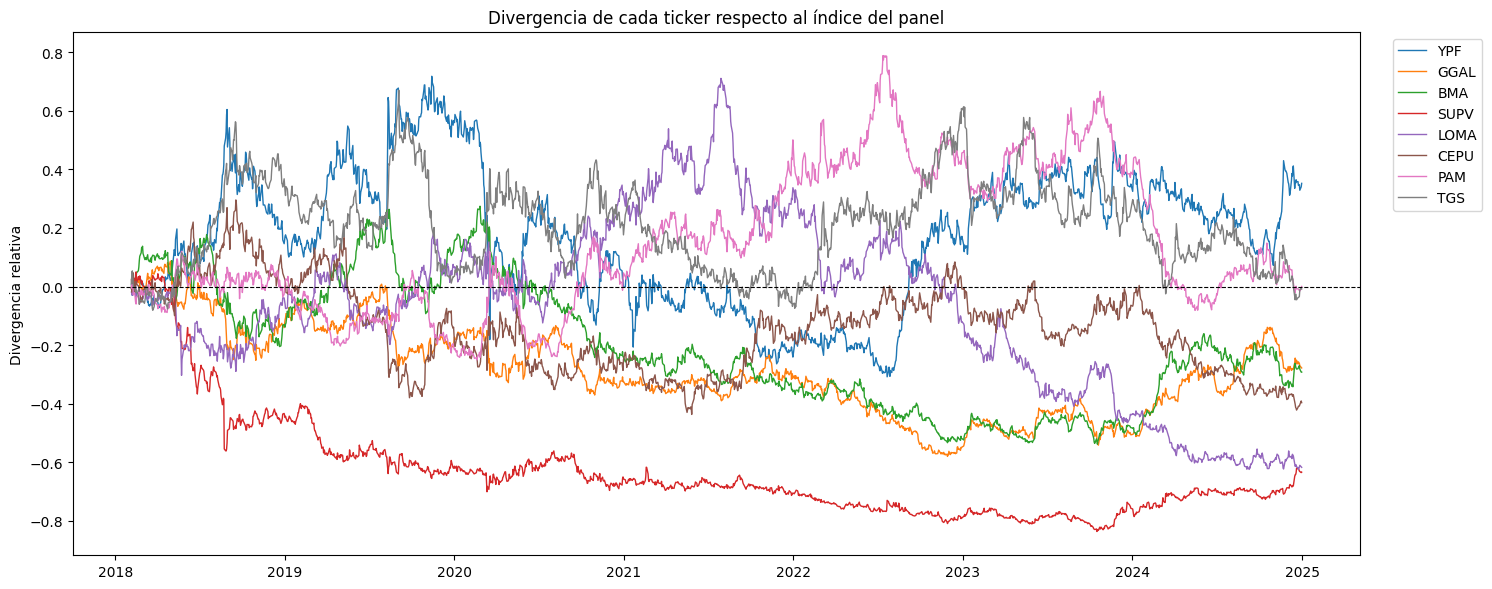

In [13]:
# Divergencia de cada ticker respecto al índice del panel

divergencias = {}

for ticker in tickers:
    retorno_acumulado_ticker = (1 + retornos_todos[ticker]).cumprod()

    # Divergencia relativa: cuánto más/menos ganó el ticker que el panel promedio
    divergencia = retorno_acumulado_ticker / indice_panel - 1
    divergencias[ticker] = divergencia

df_divergencias = pd.DataFrame(divergencias)

fig, ax = plt.subplots(figsize=(15, 6))

# Le metemos un peu de couleur 
for ticker in tickers:
    ax.plot(df_divergencias.index, df_divergencias[ticker], color=color_map[ticker], label=ticker, linewidth=1)

ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
ax.set_title('Divergencia de cada ticker respecto al índice del panel')
ax.set_ylabel('Divergencia relativa')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [19]:
# Señal de reversión: z-score rolling de la divergencia

# vamos a hacer un rolling de 60 dias
ventana_zscore = 60


def calcular_señal_reversion(ticker, umbral_z=-1.5):
    divergencia = df_divergencias[ticker].dropna()

    # Mu
    media_rolling = divergencia.rolling(ventana_zscore).mean()

    # sigma
    std_rolling = divergencia.rolling(ventana_zscore).std()

    z_score = (divergencia - media_rolling) / std_rolling

    # Primera posición:
    # Señal: si el ticker está MUY por debajo de su propia divergencia normal -> comprar 
    # si está MUY por encima -> vender / no tener posición 
    posicion = pd.Series(0, index=divergencia.index)
    posicion[z_score < umbral_z] = 1    # señal de comprar
    posicion[z_score > -umbral_z] = 0   # señal de vender

    # Creamos una serie "posicion" llena de 0s 
    posicion = posicion.replace(0, np.nan).ffill().fillna(0)  # mantenemos posición hasta señal contraria
    # Corregimos: si z vuelve a zona neutra, no necesariamente hay que salir. Definimos salida explícita:
    posicion = pd.Series(0, index=divergencia.index)
    en_posicion = False
    for fecha in divergencia.index:
        z = z_score.loc[fecha]
        if pd.isna(z):      # 1ros 59 dias no hay sufi datos para hacer rolling a 60 dias
            posicion.loc[fecha] = 0 # entonces directamente le clavamos un 0 y a otra cosa
            continue

        ############### Revisar si hay que cambiar la flag hoy ##############
        if z < umbral_z:    # Si caemos abajo del umbral -> tenemos que comprar
            en_posicion = True

        elif z > -umbral_z:  # Si superamos el -umbral -> tomamos ganancia y salimos
            en_posicion = False

        ############### Anotamos la posición definitiva para hoy ##############
        if en_posicion == True:   # Si mi flag es true, entonces señalo zona de compra
            posicion.loc[fecha] = 1

        else:                      # Si no, sigo esperando el momento 
            posicion.loc[fecha] = 0

    retornos_ticker = data[ticker].pct_change().reindex(posicion.index)
    retorno_estrategia = posicion.shift(1) * retornos_ticker

    return pd.DataFrame({
        'divergencia': divergencia,
        'z_score': z_score,
        'posicion': posicion,
        'retorno_bh': retornos_ticker,
        'retorno_estrategia': retorno_estrategia
    }).dropna()

In [25]:
# Generamos las señales

def calcular_señales_estrategia(ticker, data_precios, df_divergencias, ventana=60, umbral_z=1.5):
    divergencia = df_divergencias[ticker].dropna()

    media_rolling = divergencia.rolling(ventana).mean()
    std_rolling = divergencia.rolling(ventana).std()
    z_score = (divergencia - media_rolling) / std_rolling

    posicion = pd.Series(0, index=divergencia.index)
    en_posicion = False
    
    for fecha in divergencia.index:
        z = z_score.loc[fecha]
        if pd.isna(z):
            posicion.loc[fecha] = 0
            continue
            
        if z < -umbral_z:      # compra cuando z < -1.5
            en_posicion = True      
        elif z > umbral_z:     # venta cuando z > 1.5
            en_posicion = False     
            
        posicion.loc[fecha] = 1 if en_posicion else 0

    cambio_posicion = posicion.diff()
    es_compra = cambio_posicion == 1
    es_venta = cambio_posicion == -1

    retornos_ticker = data_precios[ticker].pct_change().reindex(posicion.index)
    retorno_estrategia = posicion.shift(1) * retornos_ticker

    df_resultados = pd.DataFrame({
        'precio': data_precios[ticker],
        'divergencia': divergencia,
        'z_score': z_score,
        'posicion': posicion,
        'señal_compra': es_compra,
        'señal_venta': es_venta,
        'retorno_bh': retornos_ticker,
        'retorno_estrategia': retorno_estrategia
    }).dropna(subset=['z_score'])
    
    return df_resultados

def obtener_tabla_trades(df_resultados, ticker_nombre):
    df_trades = df_resultados[df_resultados['señal_compra'] | df_resultados['señal_venta']].copy()
    df_trades['Acción'] = np.where(df_trades['señal_compra'], 'COMPRA', 'VENTA')
    
    # Agregamos la columna Ticker para identificarlo en la tabla general
    df_trades['Ticker'] = ticker_nombre
    
    tabla_final = df_trades[['Ticker', 'Acción', 'precio', 'z_score']].copy()
    tabla_final.index.name = 'Fecha'
    
    return tabla_final

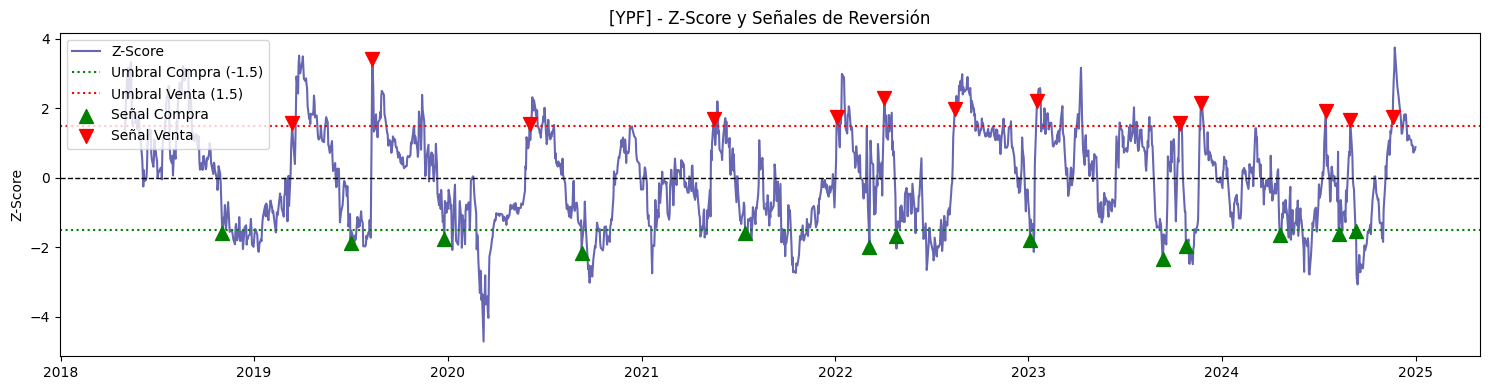

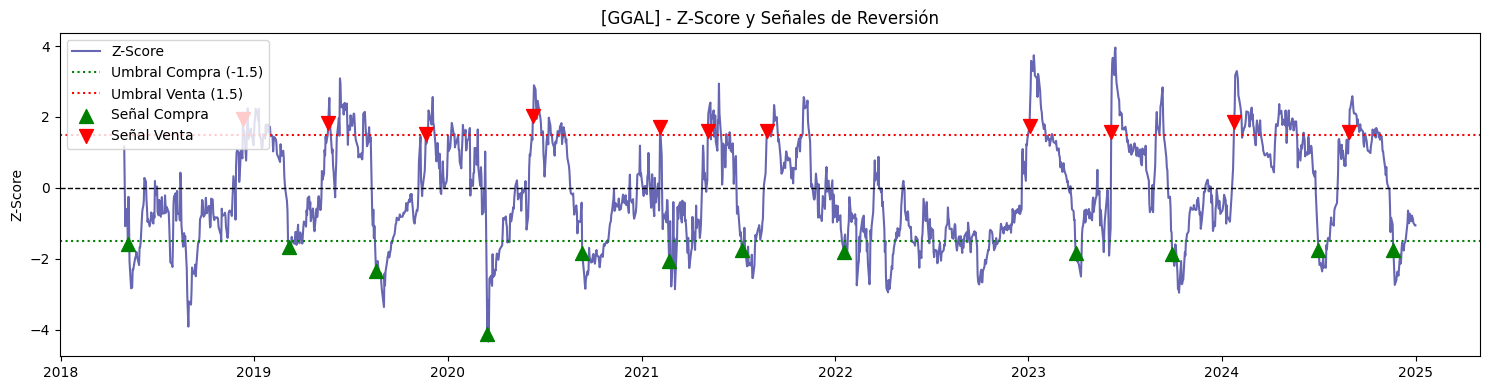

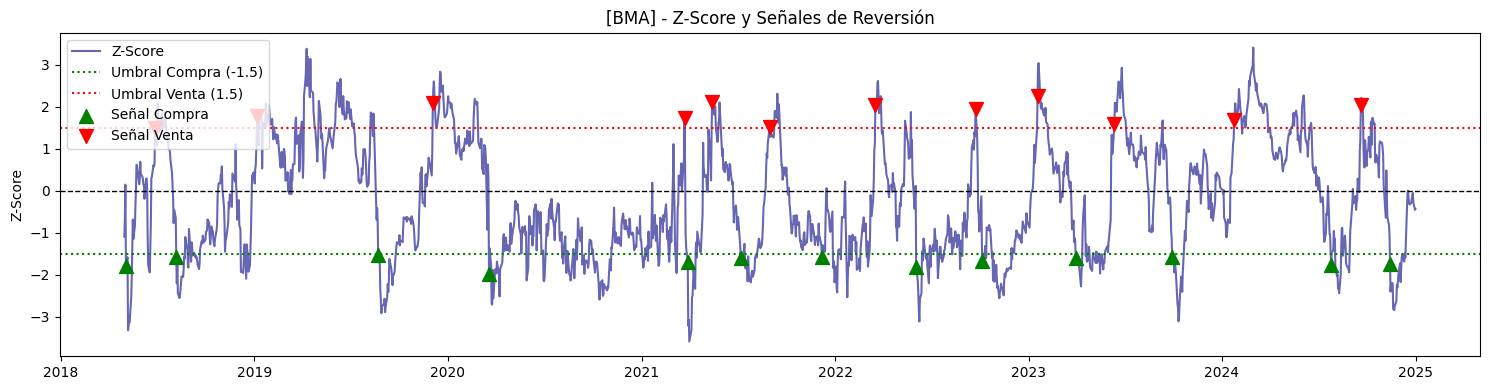

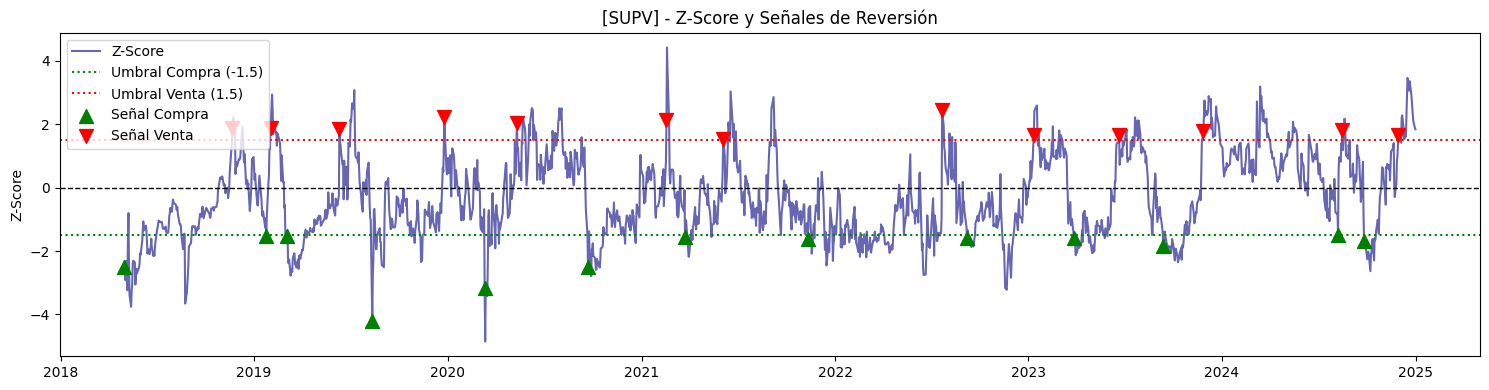

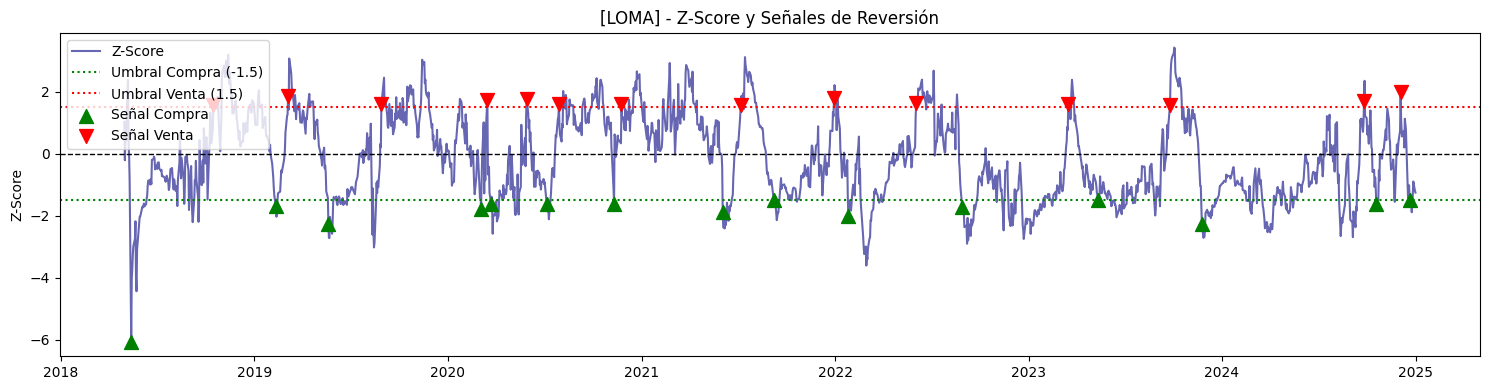

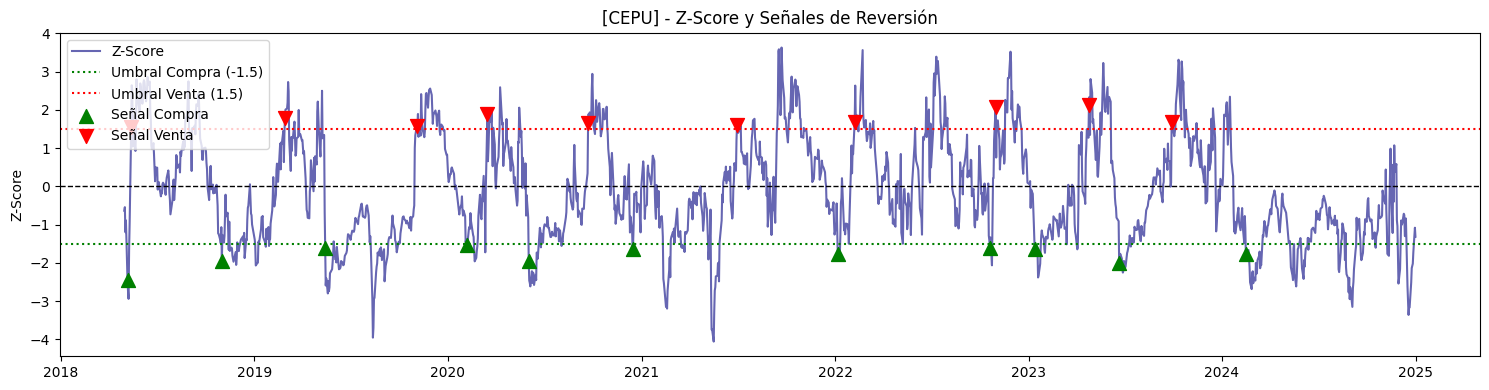

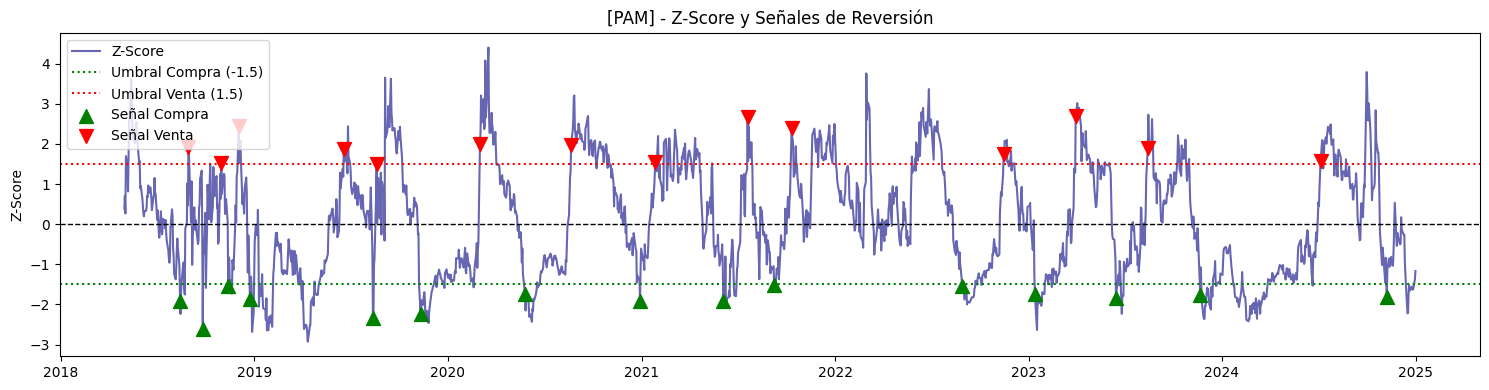

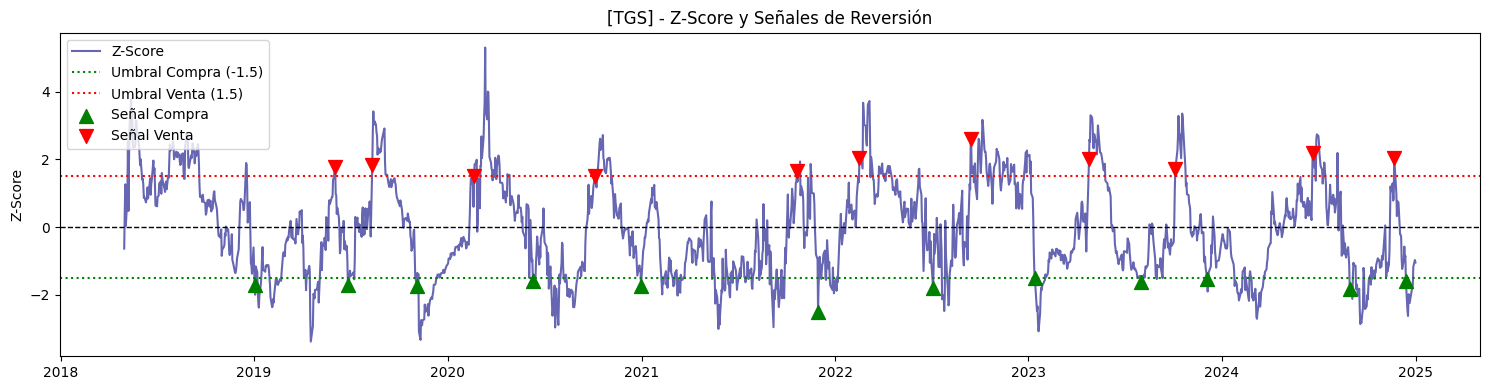

In [26]:
# Ejemplo de Uso y Visualización


resultados_estrategia = {}
lista_bitacoras = []

# Umbral de z-score (positivo: compra en -umbral_z, venta en +umbral_z)
umbral_z = 1.5

for ticker in tickers:
    # 1. Calculamos la estrategia para el ticker actual
    df_res = calcular_señales_estrategia(ticker, data, df_divergencias, ventana_zscore, umbral_z)
    resultados_estrategia[ticker] = df_res
    
    # 2. Extraemos los trades y los guardamos en una lista
    bitacora_individual = obtener_tabla_trades(df_res, ticker)
    lista_bitacoras.append(bitacora_individual)

# Iteramos de nuevo para dibujar los gráficos (uno debajo del otro)
for ticker in tickers:
    df_res = resultados_estrategia[ticker]
    
    fig, ax = plt.subplots(figsize=(15, 4))
    
    # Línea base del Z-Score
    ax.plot(df_res.index, df_res['z_score'], color='navy', alpha=0.6, label='Z-Score')
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1)
    ax.axhline(y=-umbral_z, color='green', linestyle=':', linewidth=1.5, label=f'Umbral Compra (-{umbral_z})')
    ax.axhline(y=umbral_z, color='red', linestyle=':', linewidth=1.5, label=f'Umbral Venta ({umbral_z})')
    
    # Señales de Compra
    fechas_compra = df_res[df_res['señal_compra']].index
    ax.scatter(fechas_compra, df_res.loc[fechas_compra, 'z_score'], 
               color='green', marker='^', s=100, label='Señal Compra', zorder=5)
    
    # Señales de Venta
    fechas_venta = df_res[df_res['señal_venta']].index
    ax.scatter(fechas_venta, df_res.loc[fechas_venta, 'z_score'], 
               color='red', marker='v', s=100, label='Señal Venta', zorder=5)
    
    ax.set_title(f'[{ticker}] - Z-Score y Señales de Reversión')
    ax.set_ylabel('Z-Score')
    ax.legend(loc='upper left')
    
    plt.tight_layout()
    plt.show()

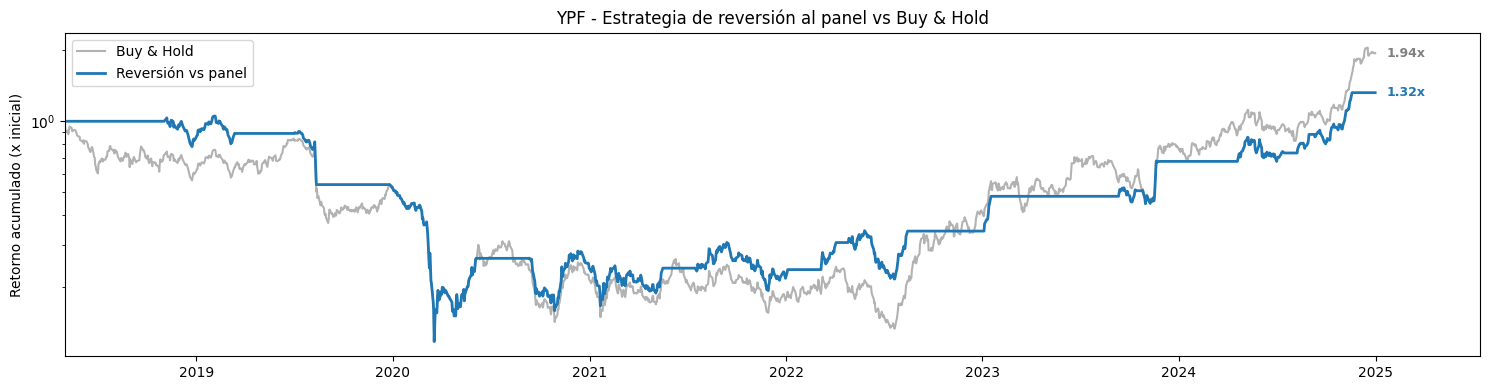

YPF: Buy & Hold 1.94x | Estrategia 1.32x


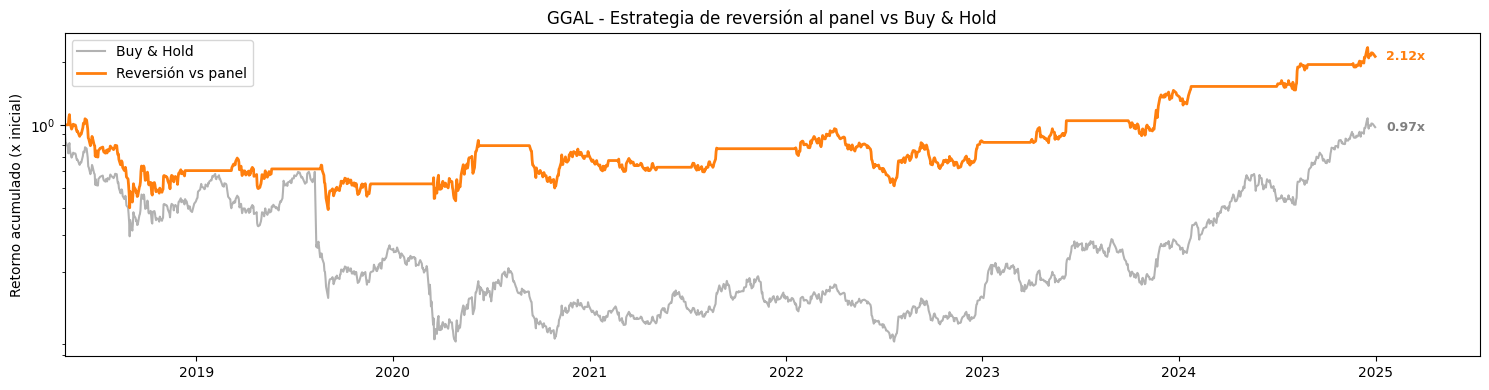

GGAL: Buy & Hold 0.97x | Estrategia 2.12x


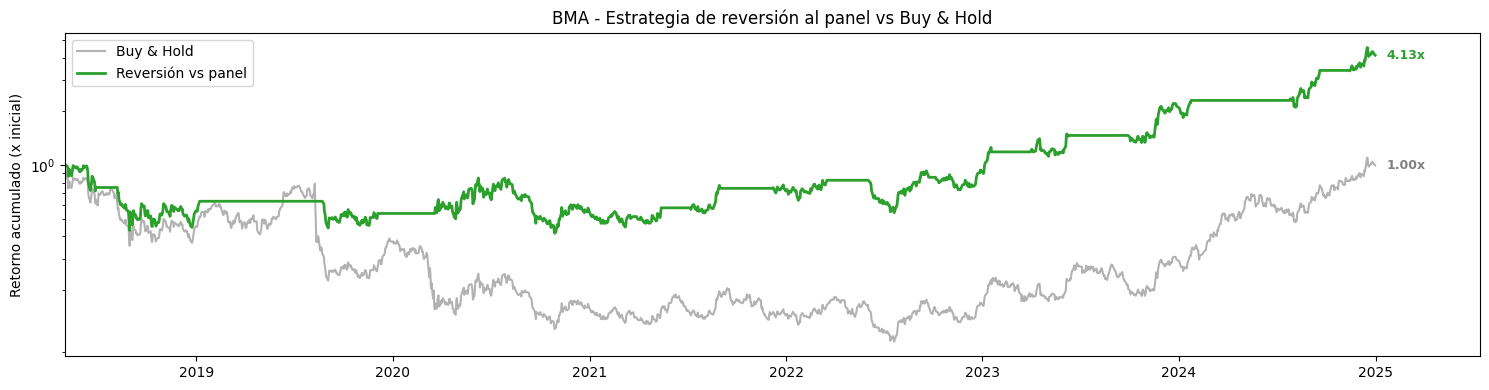

BMA: Buy & Hold 1.00x | Estrategia 4.13x


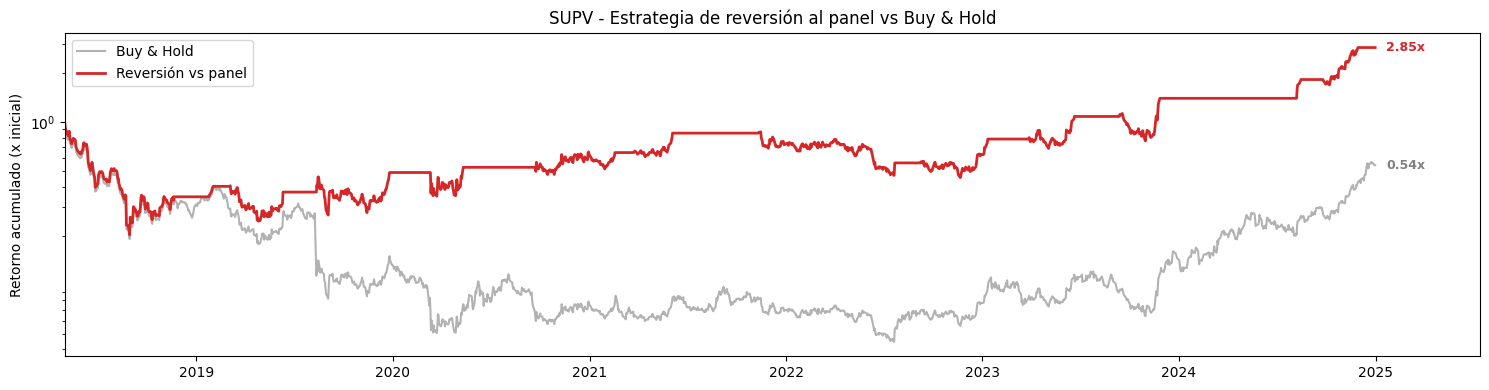

SUPV: Buy & Hold 0.54x | Estrategia 2.85x


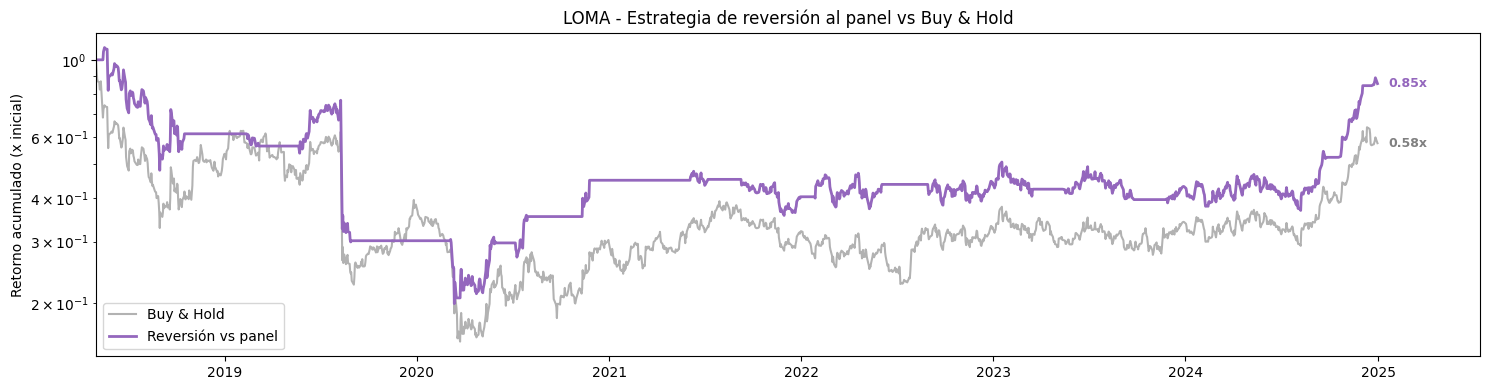

LOMA: Buy & Hold 0.58x | Estrategia 0.85x


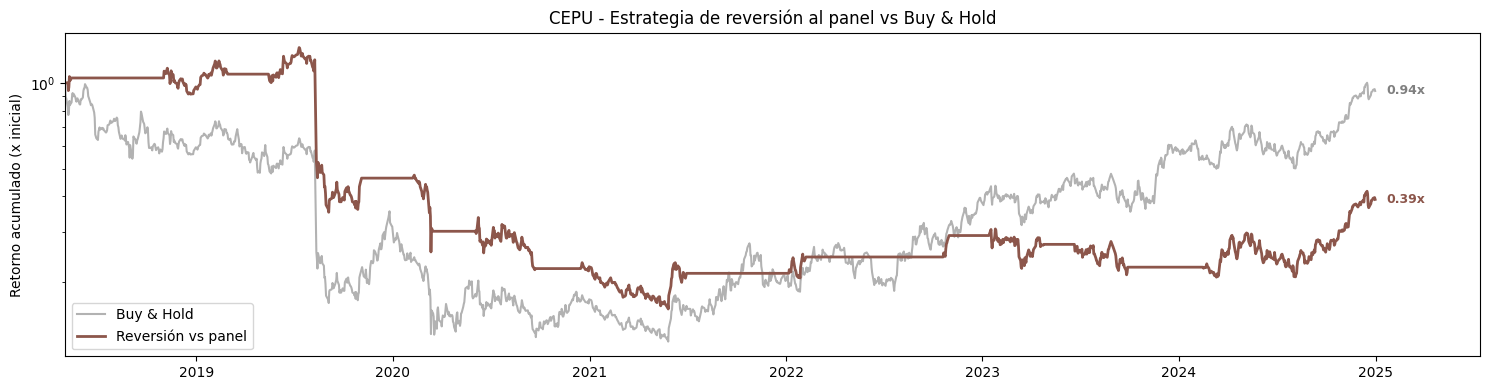

CEPU: Buy & Hold 0.94x | Estrategia 0.39x


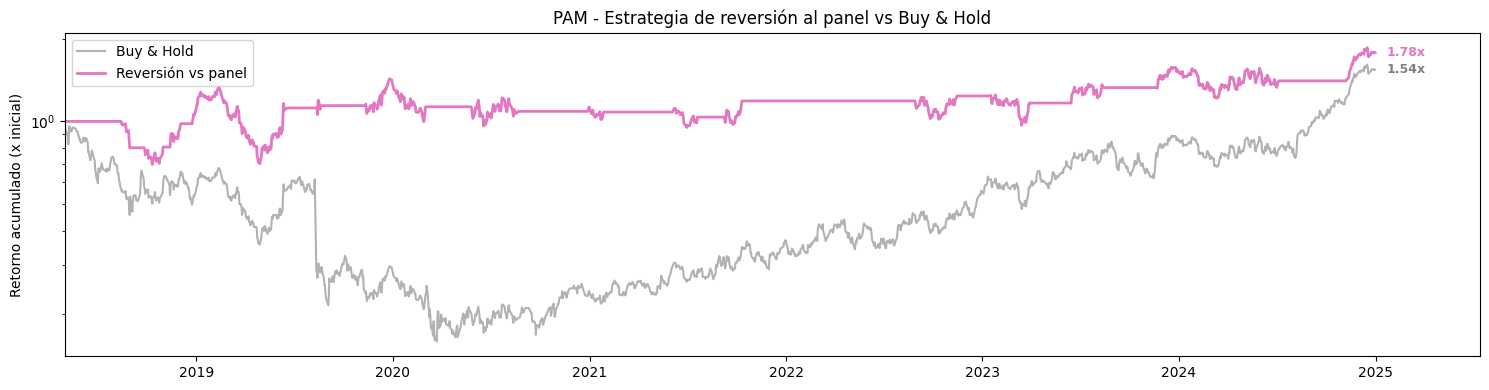

PAM: Buy & Hold 1.54x | Estrategia 1.78x


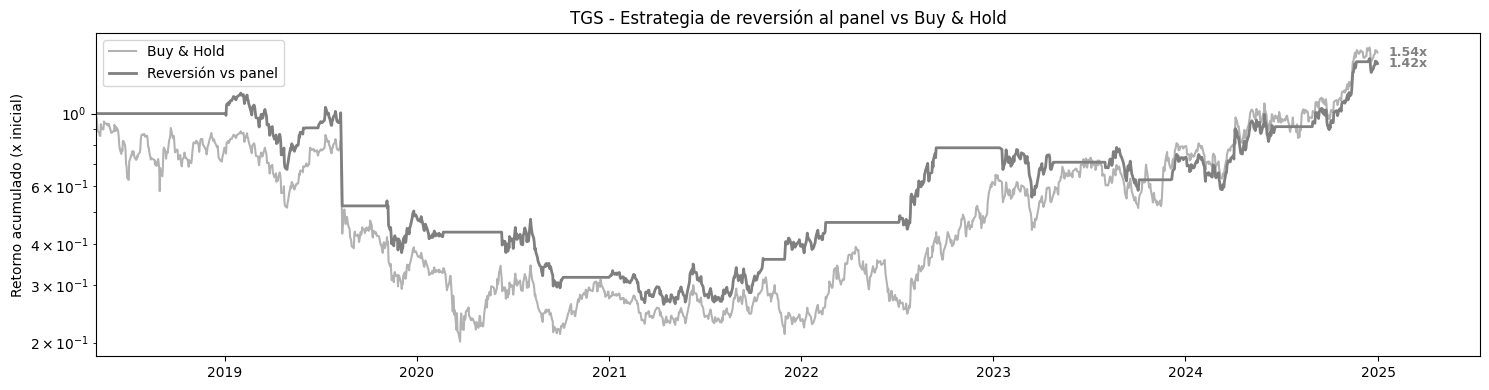

TGS: Buy & Hold 1.54x | Estrategia 1.42x


In [27]:
resultados_reversion = {}

for ticker in tickers:
    resultado = calcular_señal_reversion(ticker)
    resultados_reversion[ticker] = resultado

    acumulado_bh = (1 + resultado['retorno_bh']).cumprod()
    acumulado_estrategia = (1 + resultado['retorno_estrategia']).cumprod()

    plt.figure(figsize=(15, 4))
    plt.plot(resultado.index, acumulado_bh, label='Buy & Hold', color='gray', alpha=0.6)
    plt.plot(resultado.index, acumulado_estrategia, label='Reversión vs panel', color=color_map[ticker], linewidth=2)

    # Anotamos el valor final (x inicial) de cada curva
    plt.annotate(f'{acumulado_bh.iloc[-1]:.2f}x',
                 xy=(resultado.index[-1], acumulado_bh.iloc[-1]),
                 xytext=(8, 0), textcoords='offset points',
                 va='center', fontsize=9, color='gray', weight='bold')

    plt.annotate(f'{acumulado_estrategia.iloc[-1]:.2f}x',
                 xy=(resultado.index[-1], acumulado_estrategia.iloc[-1]),
                 xytext=(8, 0), textcoords='offset points',
                 va='center', fontsize=9, color=color_map[ticker], weight='bold')

    plt.title(f'{ticker} - Estrategia de reversión al panel vs Buy & Hold')
    plt.ylabel('Retorno acumulado (x inicial)')
    plt.yscale('log')
    plt.yticks([1], ['$10^0$'])
    plt.xlim(resultado.index[0], resultado.index[-1] + (resultado.index[-1] - resultado.index[0]) * 0.08)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f'{ticker}: Buy & Hold {acumulado_bh.iloc[-1]:.2f}x | Estrategia {acumulado_estrategia.iloc[-1]:.2f}x')

## Comparación Z-score vs Butterworth

Hasta ahora probamos implementar Z-score como Pair Trading para generar señales de compra.

Queremos compararlo con otra estrategia, Butterworh, que utiliza una filosofía totalmente distinta:

### ¿Qué es Butterworth?

El filtro Butterworth es un filtro digital clásico de procesamiento de señales que se usa para suavizar una serie, eliminando el ruido de corto plazo y dejando pasar solo la tendencia de fondo.

En nuestro caso, lo aplicamos de forma *rolling* (recalculándolo día a día, usando solo los datos disponibles hasta ese momento, sin mirar el futuro) para obtener una versión suavizada del precio en tiempo real. 

A partir de esa tendencia:

1. Calculamos el **momentum**: cuánto subió o bajó la tendencia suavizada en los últimos 20 días.
2. Definimos un **régimen**: alcista si el momentum supera +3%, bajista si cae por debajo de -3%, y se mantiene el último régimen conocido en la zona neutra.
3. Convertimos el régimen en una **posición**: comprado (long) solo si el régimen es alcista, afuera del mercado en cualquier otro caso.

Es, en esencia, una estrategia de **seguimiento de tendencia**: apuesta a que una acción que viene subiendo va a seguir subiendo, y sale del mercado cuando esa tendencia se pierde.

Vale la pena compararla directamente con Z-score porque responden preguntas distintas sobre el mismo mercado: 
- Dado que ya confirmamos que las acciones argentinas de este panel están fuertemente correlacionadas, **queremos saber si conviene más apostar a que cada acción siga su propia tendencia o a que las divergencias respecto al grupo se corrijan.**

In [16]:
# Filtro Butterworth rolling 

def butterworth_filter(serie, cutoff, fs=1, order=4):
    nyq = fs / 2
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low')
    return filtfilt(b, a, serie)


def calcular_estrategia_butterworth(ticker, cutoff=0.05, ventana_momentum=20, umbral_momentum=0.03, ventana_min=30):
    precios = data[ticker].dropna()
    fechas = precios.index
    precios_vals = precios.values

    filtrado = []
    for i in range(len(precios_vals)):
        if i < ventana_min:
            filtrado.append(np.nan)
        else:
            segmento = precios_vals[:i+1]
            f = butterworth_filter(segmento, cutoff=cutoff)
            filtrado.append(f[-1])
    filtrado = np.array(filtrado)

    mask = ~np.isnan(filtrado)
    fechas, precios_vals, filtrado = fechas[mask], precios_vals[mask], filtrado[mask]

    filtrado_s = pd.Series(filtrado, index=fechas)
    momentum = filtrado_s.pct_change(ventana_momentum)

    regimen = pd.Series(index=fechas, dtype=float)
    regimen[momentum > umbral_momentum] = 1
    regimen[momentum < -umbral_momentum] = -1
    regimen = regimen.ffill().fillna(0)

    posicion = (regimen == 1).astype(int)

    retornos_reales = pd.Series(precios_vals, index=fechas).pct_change()
    retorno_estrategia = posicion.shift(1) * retornos_reales

    return pd.DataFrame({
        'precio': precios_vals,
        'filtrado': filtrado,
        'regimen': regimen,
        'posicion': posicion,
        'retorno_bh': retornos_reales,
        'retorno_estrategia': retorno_estrategia
    }, index=fechas).dropna()


resultados_butterworth = {}

for ticker in tickers:
    resultados_butterworth[ticker] = calcular_estrategia_butterworth(ticker)

In [17]:
# Tabla comparativa: Buy & Hold vs Butterworth vs Z-score

comparacion = []

for ticker in tickers:
    # Buy & Hold (tomamos el de la corrida de z-score, es el mismo precio real)
    acumulado_bh = (1 + resultados_reversion[ticker]['retorno_bh']).cumprod()

    # Butterworth
    acumulado_butter = (1 + resultados_butterworth[ticker]['retorno_estrategia']).cumprod()

    # Z-score
    acumulado_zscore = (1 + resultados_reversion[ticker]['retorno_estrategia']).cumprod()

    comparacion.append({
        'ticker': ticker,
        'buy_and_hold_x': round(acumulado_bh.iloc[-1], 2),
        'butterworth_x': round(acumulado_butter.iloc[-1], 2),
        'zscore_x': round(acumulado_zscore.iloc[-1], 2),
    })

df_comparacion = pd.DataFrame(comparacion).set_index('ticker')
df_comparacion['ganador'] = df_comparacion[['buy_and_hold_x', 'butterworth_x', 'zscore_x']].idxmax(axis=1)

df_comparacion

,buy_and_hold_x,butterworth_x,zscore_x,ganador
ticker,,,,
YPF,1.94,6.28,1.32,butterworth_x
GGAL,0.97,62.20,2.12,butterworth_x
BMA,1.00,17.84,4.13,butterworth_x
SUPV,0.54,1.60,2.85,zscore_x
LOMA,0.58,0.33,0.85,zscore_x
CEPU,0.94,1.41,0.39,butterworth_x
PAM,1.54,5.47,1.78,butterworth_x
TGS,1.54,2.47,1.42,butterworth_x


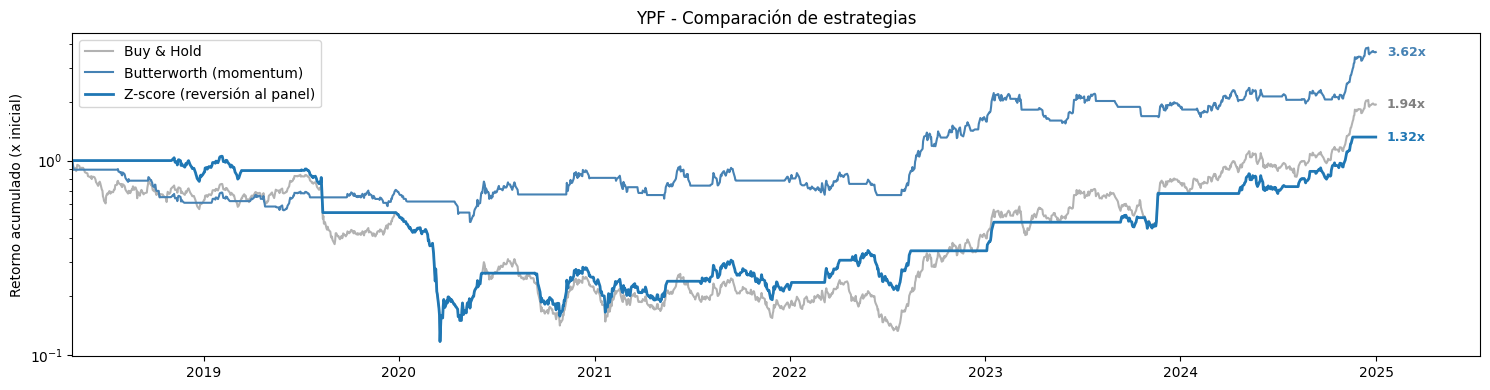

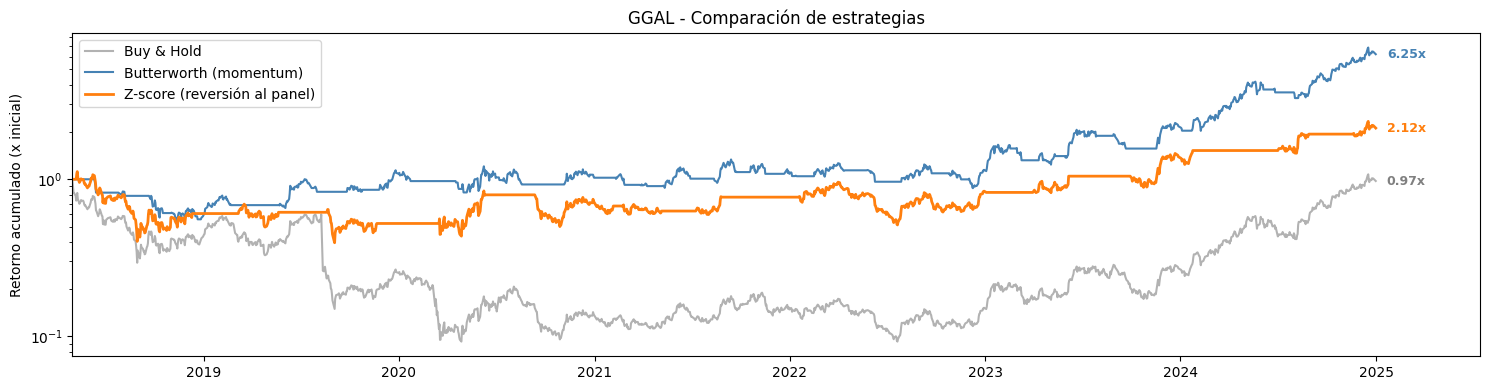

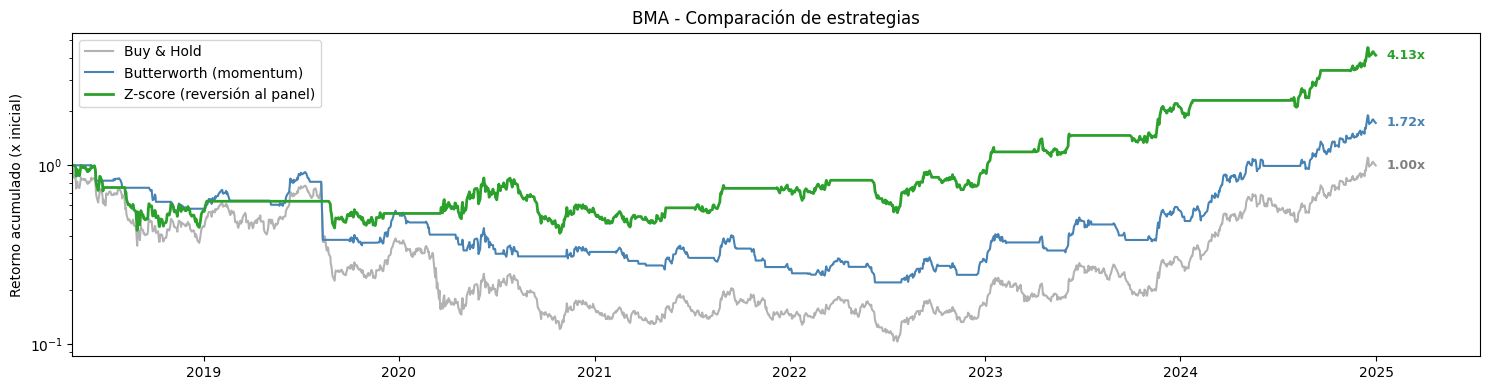

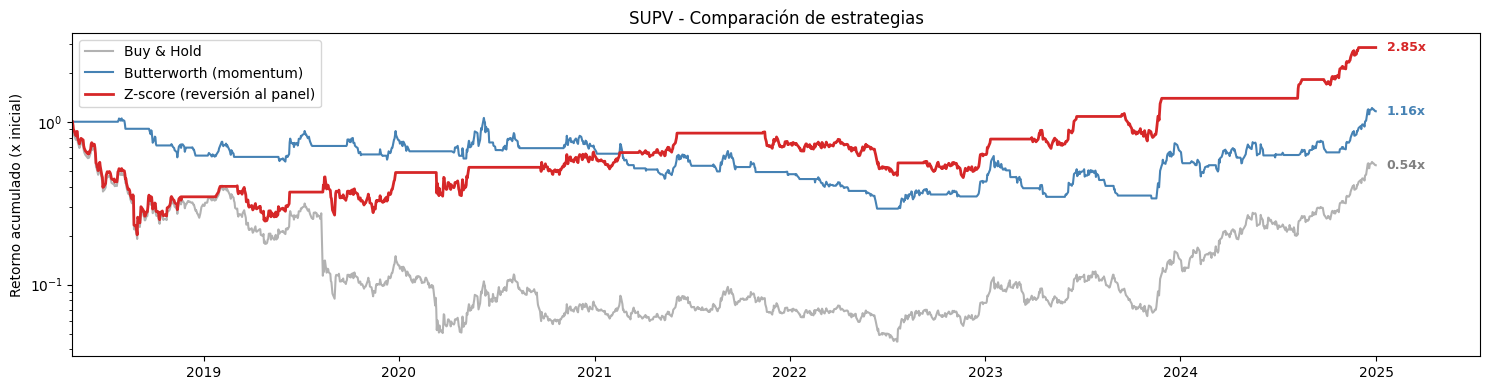

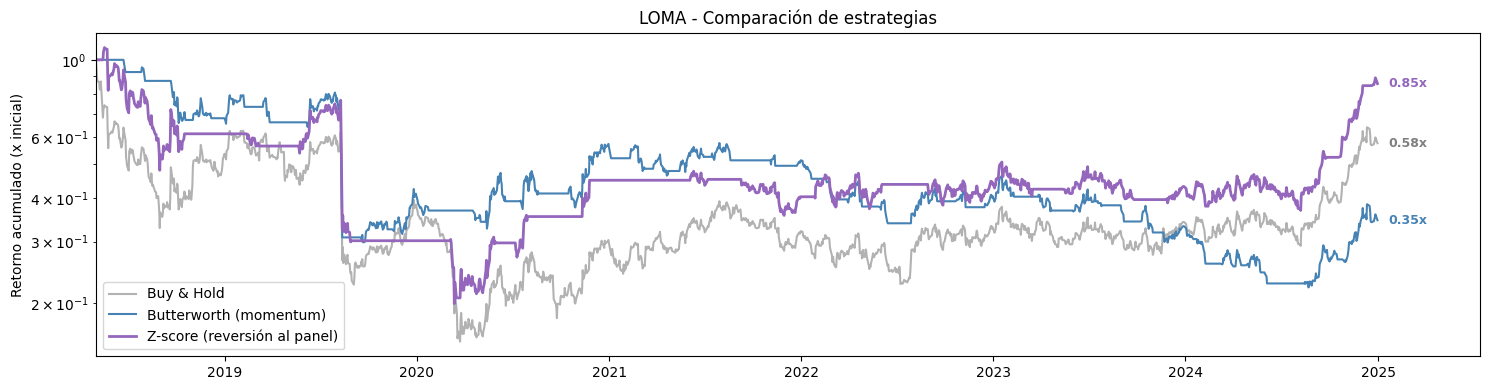

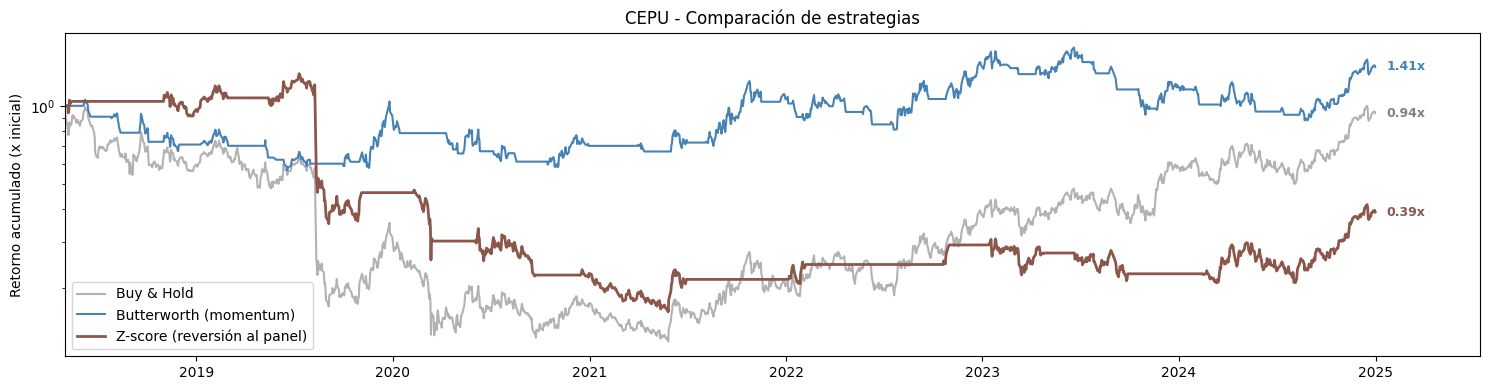

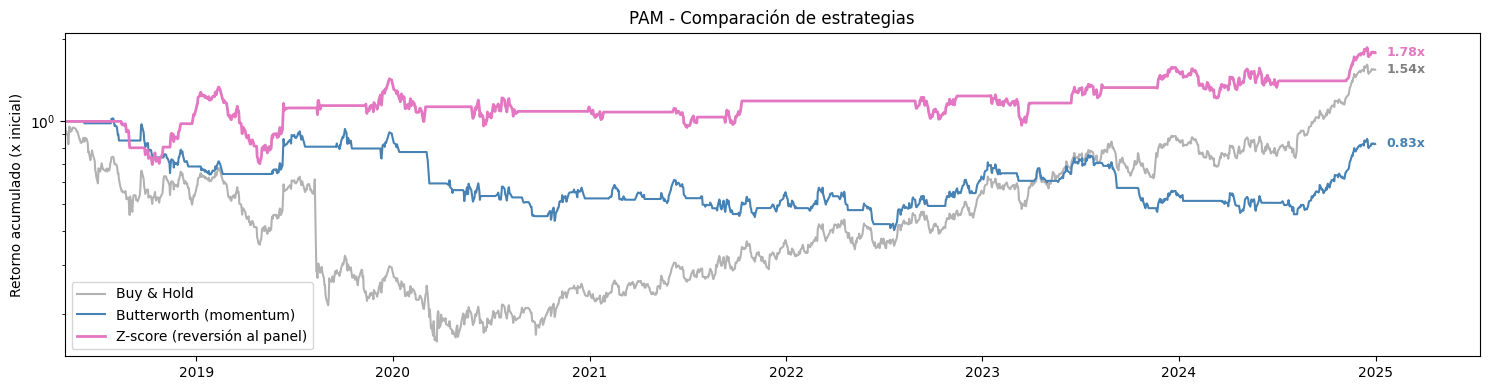

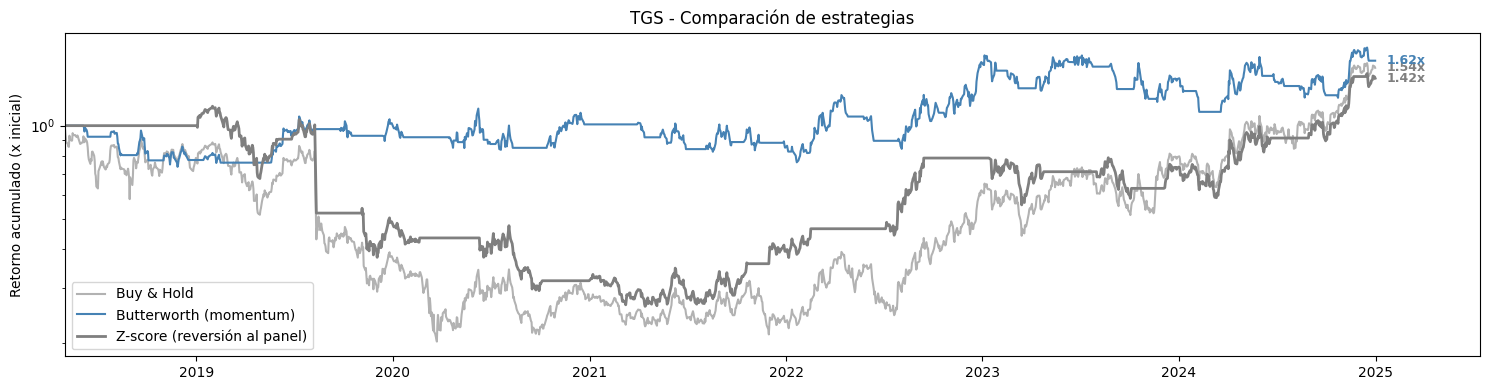

In [18]:
# Comparación de estrategias

for ticker in tickers:
    # Recortamos Buy & Hold y Butterworth al mismo rango de fechas que z-score
    fecha_inicio_comun = resultados_reversion[ticker].index[0]

    bh_recortado = resultados_reversion[ticker]['retorno_bh']
    butter_recortado = resultados_butterworth[ticker]['retorno_estrategia']
    butter_recortado = butter_recortado[butter_recortado.index >= fecha_inicio_comun]

    acumulado_bh = (1 + bh_recortado).cumprod()
    acumulado_butter = (1 + butter_recortado).cumprod()
    acumulado_zscore = (1 + resultados_reversion[ticker]['retorno_estrategia']).cumprod()

    plt.figure(figsize=(15, 4))
    plt.plot(acumulado_bh.index, acumulado_bh, label='Buy & Hold', color='gray', alpha=0.6)
    plt.plot(acumulado_butter.index, acumulado_butter, label='Butterworth (momentum)', color='steelblue', linewidth=1.5)
    plt.plot(acumulado_zscore.index, acumulado_zscore, label='Z-score (reversión al panel)', color=color_map[ticker], linewidth=2)

    # Anotamos el valor final (profit) de cada curva
    plt.annotate(f'{acumulado_bh.iloc[-1]:.2f}x',
                 xy=(acumulado_bh.index[-1], acumulado_bh.iloc[-1]),
                 xytext=(8, 0), textcoords='offset points',
                 va='center', fontsize=9, color='gray', weight='bold')

    plt.annotate(f'{acumulado_butter.iloc[-1]:.2f}x',
                 xy=(acumulado_butter.index[-1], acumulado_butter.iloc[-1]),
                 xytext=(8, 0), textcoords='offset points',
                 va='center', fontsize=9, color='steelblue', weight='bold')

    plt.annotate(f'{acumulado_zscore.iloc[-1]:.2f}x',
                 xy=(acumulado_zscore.index[-1], acumulado_zscore.iloc[-1]),
                 xytext=(8, 0), textcoords='offset points',
                 va='center', fontsize=9, color=color_map[ticker], weight='bold')

    plt.title(f'{ticker} - Comparación de estrategias')
    plt.ylabel('Retorno acumulado (x inicial)')
    plt.yscale('log')
    plt.xlim(acumulado_bh.index[0], acumulado_bh.index[-1] + (acumulado_bh.index[-1] - acumulado_bh.index[0]) * 0.08)
    plt.legend()
    plt.tight_layout()
    plt.show()

## Conclusión de la comparación

Lo que encontramos es que ninguna de las dos estrategias es sistemáticamente mejor que la otra: hay veces que gana Butterworth, y otras veces gana el z-score. El resultado está repartido.

Esto sugiere que ninguna de las dos lógicas de trading captura por sí sola el comportamiento completo del mercado argentino. Hay momentos donde conviene seguir la tendencia individual de la acción (Butterworth), y otros donde conviene apostar a la reversión relativa al panel (z-score).

En vez de elegir una sola estrategia, el siguiente paso natural sería explorar una combinación de ambas, buscando mejorar la calidad de las señales de compra y venta.